In this simple notebook we use a fully connected neural network to solve a previously seen problem in regression: the photometric redshift problem (see notebooks of Chapter 6 for more detail). We also explore some hyperparameter optimization strategies. 

It accompanies Chapter 8 of the book (2 of 2).

Copyright: Viviana Acquaviva (2023).

Modifications by Julieta Gruszko (2025)

License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)



In [3]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler

In [5]:
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 150)

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
matplotlib.rcParams['figure.dpi'] = 300

In [6]:
import torch as torch

In [7]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [8]:
import keras

from keras import Input

from keras.models import Sequential #the model is built adding layers one after the other

from keras.layers import Dense #fully connected layers: every output talks to every input

from keras.layers import Dropout #for regularization

### Problem 2: photometric redshifts

I will start out from the reduced (high-quality) data set we used for Bagging and Boosting methods. For reference, our best model achieved a NMAD around 0.02 and an outlier fraction of 4%.

In [9]:
X = pd.read_csv('../Data/sel_features.csv', sep = '\t')
y = pd.read_csv('../Data/sel_target.csv')

In [10]:
X,y = shuffle(X,y, random_state = 12)

Just a reminder of what's in here:

In [11]:
display(X)

,u_apercor,g_apercor,r_apercor,i_apercor,z_apercor,y_apercor
4561,23.7774,23.4961,23.2445,22.9700,22.5860,22.4497
3675,23.7430,23.3638,22.6674,21.7934,21.2195,21.0882
3201,24.1826,23.1667,22.6836,22.4811,22.3890,22.4926
780,23.6480,23.2737,22.6016,22.3798,22.3236,22.3666
4205,24.0790,23.7875,23.3592,22.6754,22.4678,22.4220
...,...,...,...,...,...,...
3714,25.7334,24.1034,22.7085,21.7983,21.4909,21.4430
3325,23.6960,22.8077,22.1069,21.8567,21.7051,21.6484
1414,23.4466,23.2365,22.8977,22.2802,22.0043,21.6886
5787,23.7682,23.5955,23.2167,22.6452,22.4907,22.5384


In [12]:
fifth = int(len(y)/5) #Divide data in fifths to use 60/20/20 split

In [13]:
X_train = X.values[:3*fifth,:]
y_train = y[:3*fifth]

X_val = X.values[3*fifth:4*fifth,:]
y_val = y[3*fifth:4*fifth]

X_test = X.values[4*fifth:,:]
y_test = y[4*fifth:]

In [14]:
X_train.shape

(3783, 6)

We know that we need to scale our data!

In [15]:
scaler = StandardScaler()

scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [16]:
Xst_train = scaler.transform(X_train)
Xst_val = scaler.transform(X_val)
Xst_test = scaler.transform(X_test)

In a regression problem, we will choose a different activation for the output layer (e.g. linear), and an appropriate loss function (MSE, MAE, ...).

Our input layer has six neurons for this problem.

For other parameters and the network structure, we can start with two layers with 100 neurons and go from there.

In [17]:
model = Sequential()

# Tell subsequent layers what shape to expect
model.add(keras.Input(shape=(6,)))

optimizer = keras.optimizers.AdamW(learning_rate=0.001)

# Add an input layer and specify its size (number of original features)

model.add(Dense(100, activation='relu', input_shape=(6,)))

# Add one hidden layer and specify its size

model.add(Dense(100, activation='relu'))

# Add an output layer 

model.add(Dense(1, activation='linear'))

model.compile(loss='mse', optimizer=optimizer)


/opt/anaconda3/envs/phy448_deeplearning/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We begin with 100 epochs and batch size = 300.

In [18]:
mynet = model.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=300)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.3228 - val_loss: 0.2236
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1761 - val_loss: 0.1143
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0948 - val_loss: 0.0613
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0611 - val_loss: 0.0415
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0496 - val_loss: 0.0355
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0463 - val_loss: 0.0327
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0439 - val_loss: 0.0320
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0429 - val_loss: 0.0316
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0418 - val_loss: 0.0302
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0404 - val_loss: 0.0297
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0397 - val_loss: 0.0282
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

In [19]:
results = model.evaluate(Xst_test, y_test)
print('MSE:', results) #we are only monitoring the MSE

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0278
MSE: 0.02783052623271942


As usual, we can plot the loss throughout the training process.

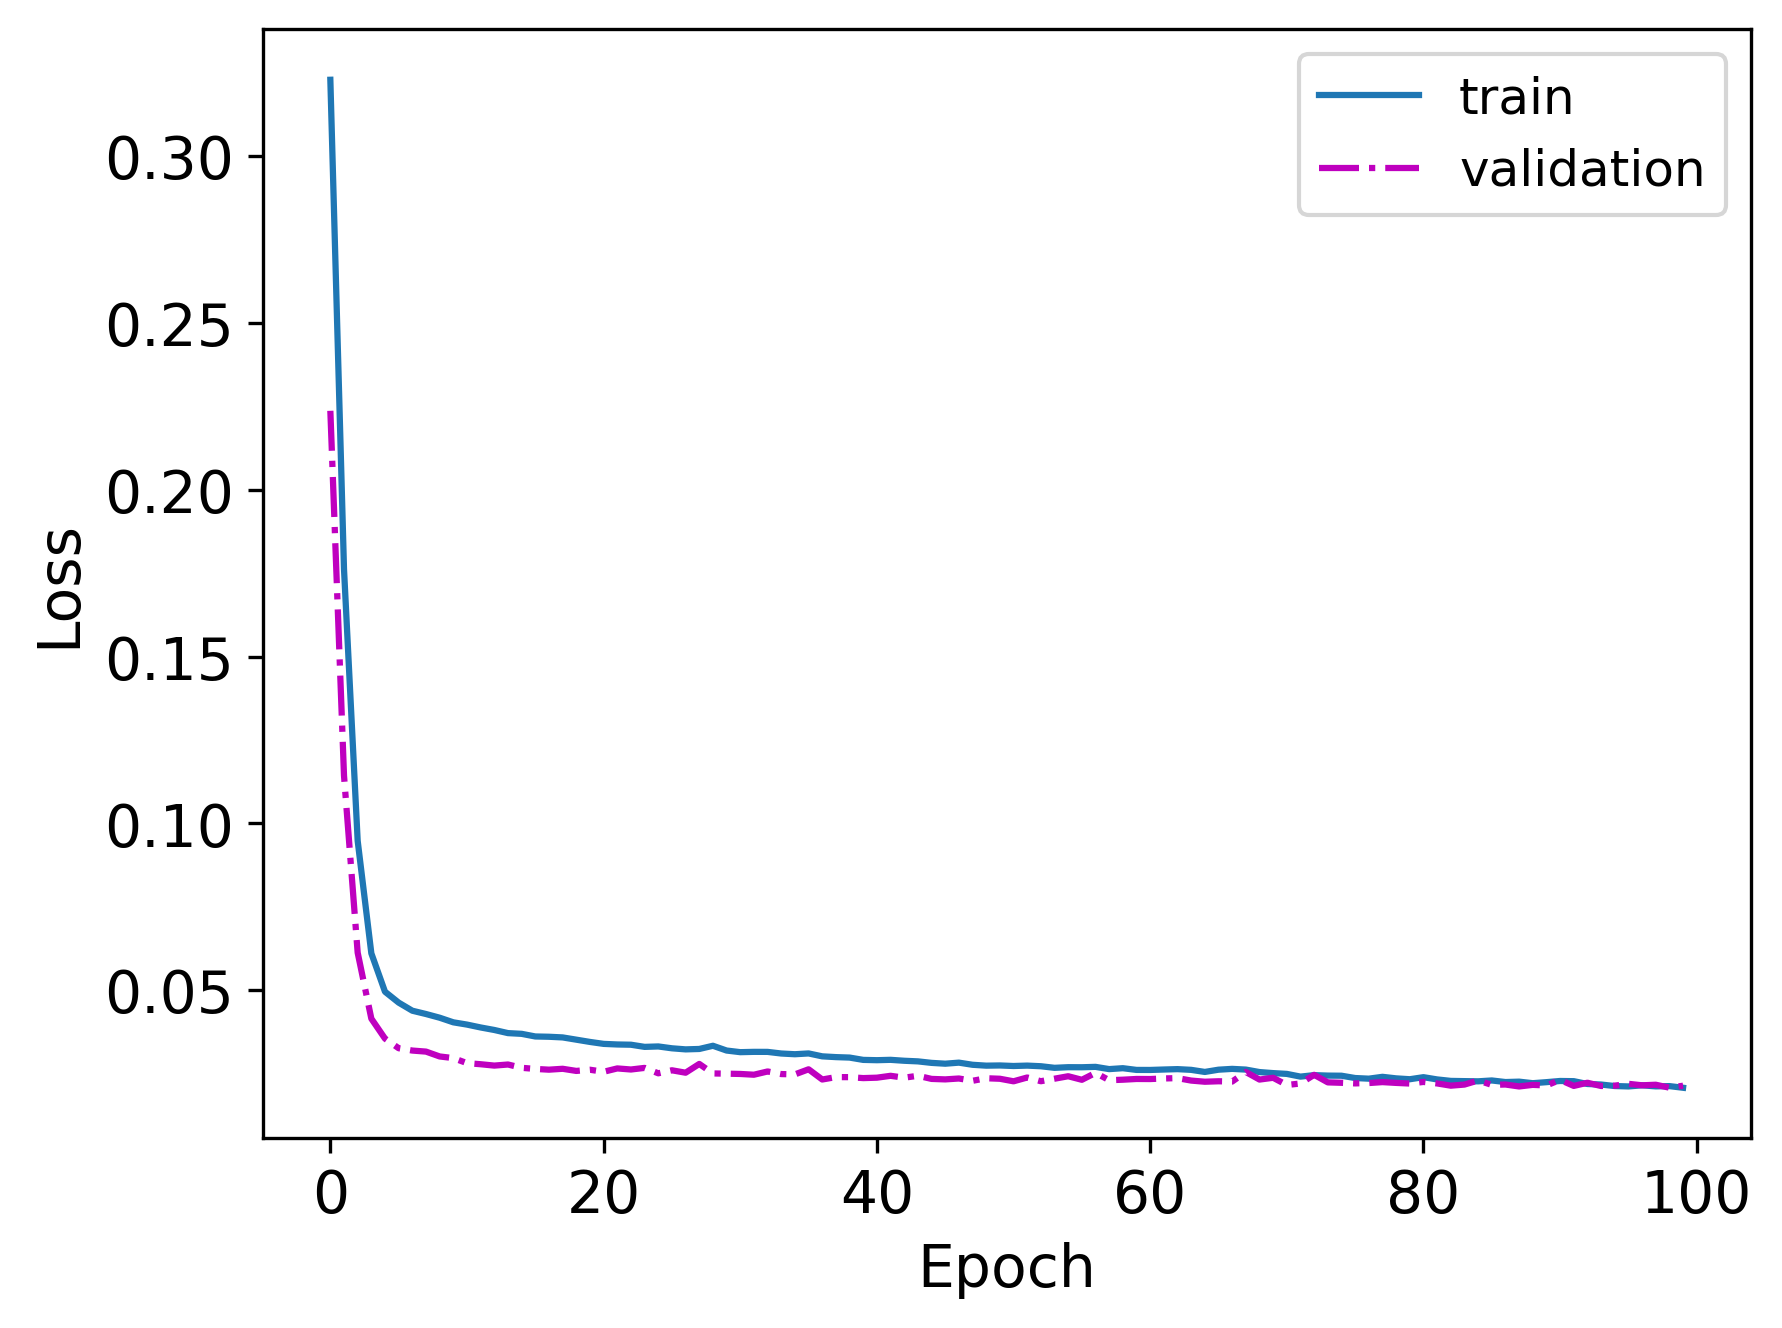

In [20]:
plt.plot(mynet.history['loss'], label = 'train')
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)
plt.legend(fontsize = 12);
#plt.savefig('Photoz_NN.png')

### As always with regression problems, it is helpful to plot the predictions against the true values.



40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


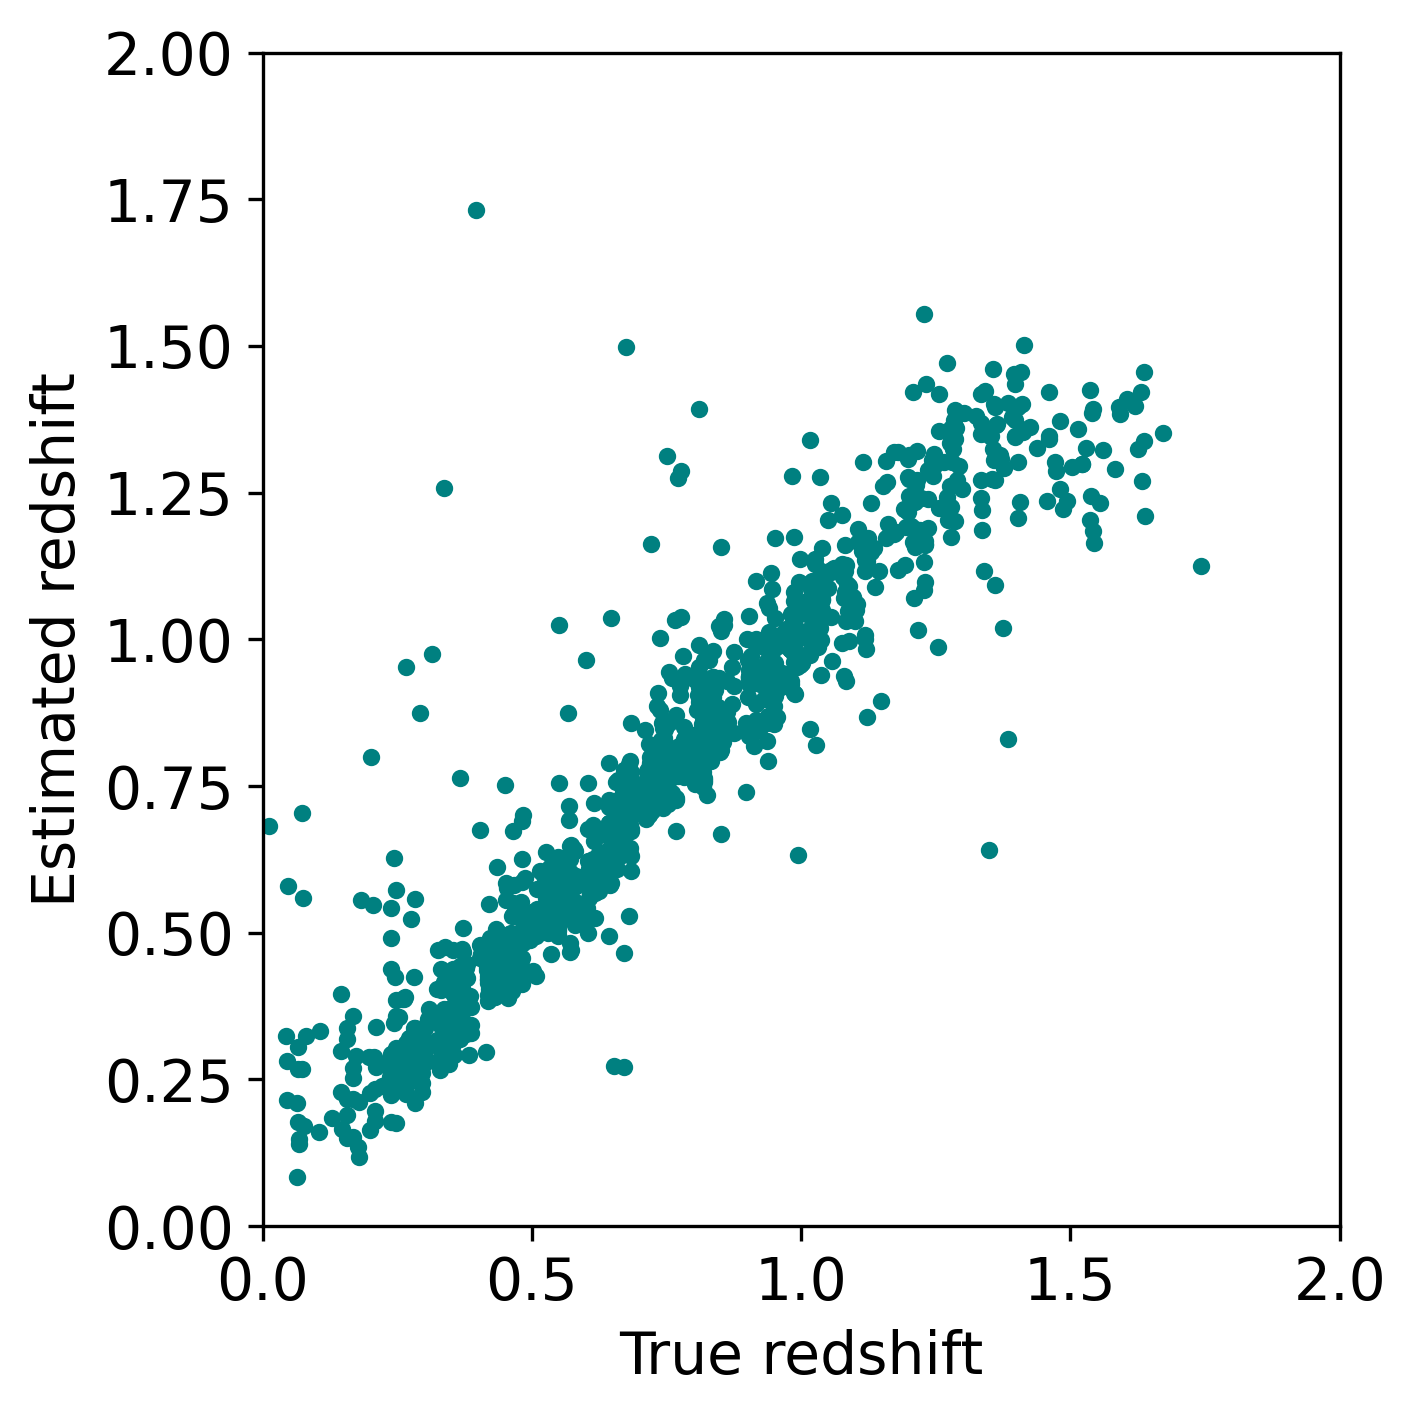

In [21]:
plt.figure(figsize=(5,5))
    
plt.xlabel('True redshift', fontsize = 14)
plt.ylabel('Estimated redshift', fontsize = 14)

plt.scatter(y_test, model.predict(Xst_test), s =10, c = 'teal');

plt.xlim(0,2)
plt.ylim(0,2)
plt.tight_layout()
#plt.savefig('Photoz_NN_scatter.png')

We didn't do cross validation, so we can only generate prediction on our single test fold in order to derive the other metrics we are interested in (OLF and NMAD).

In [22]:
ypred = model.predict(Xst_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Calculate Outlier Fraction

In [23]:
len(np.where(np.abs(y_test-ypred)>0.15*(1+y_test))[0])/len(y_test)

0.04592240696753761

Calculate Normalized Median Absolute Deviation (NMAD)

In [24]:
1.48*np.median(np.abs(y_test-ypred)/(1 + y_test))

np.float64(0.03529368624540441)

We have decent, but not outstanding, numbers. We can play with/optimize the parameters; one thing that is very interesting IMO is to see the effect of using different losses on the residuals, and trying to add more layers.

### Let's try some optimization with keras tuner

In [25]:

from keras_tuner.tuners import RandomSearch
from keras import layers

#Some material below is adapted from the Keras Tuner documentation

# https://keras-team.github.io/keras-tuner/

This function specifies which parameters we want to tune. Tunable parameters can be of type "Choice" (we specify a set), Int, Boolean, or Float.

Keras-tuner has a lot of other options for how to set up hyperparameters, check out the API to see more: https://keras.io/keras_tuner/api/hyperparameters/
It even has ways to set up conditional hyperparameters, so you don't explore meaningless combinations of hyperparameters (which was an issue with our sk-learn hyperparameter searches).

In [26]:
def build_model(hp):
    model = keras.Sequential()
    for i in range(hp.Int('num_layers', 2, 6)): #We try between 2 and 6 layers
        model.add(layers.Dense(units=hp.Int('units_' + str(i),
                                            min_value=100, #Each of them has 100-300 neurons, in intervals of 100
                                            max_value=300,
                                            step=100),
                               activation='relu'))
    model.add(Dense(1, activation='linear')) #last one
    model.compile(
        optimizer=keras.optimizers.AdamW(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])), #And a few learning rates
        loss='mse')
    return model

### Question:
List the hyperparameters being optimized and briefly describe what each one does.

>num_layers: the number of hidden layers

>units_: the number of neurons in the hidden layers

>learning_rate: the learning rate for AdamW. controls how fast the hyperparameters converge. 

Next, we specify how we want to explore the parameter space. The Random Search is the simplest choice, but often quite effective; alternatives are Hyperband (optimized Random Search where a larger fraction of models is trained for a smaller number of epochs, but only the most promising ones survive), or Bayesian Optimization, which attempts to build a probabilistic interpretation of the model scores (the posterior probability of obtaining score x, given the values of hyperparameters).


Normally, you'd try something like 40 models, at least, but this takes far too long to run for a studio (about 35 minutes, on my laptop). I've left the output of that full search below so you can see what happens, but we'll run an abbreviated search for now, so you can see how it works.

In [27]:
keras.backend.clear_session()
# This is an example of the settings you'd use for a more complete hyperparameter search
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=40, #number of combinations to try
    executions_per_trial=3,
    project_name='My Drive/Photoz') #may need to delete or reset

In [28]:
keras.backend.clear_session()

tuner_small = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5, # too small for real use! Just showing you how it works
    executions_per_trial=3,
    project_name='My Drive/Photoz_small') #may need to delete or reset. This will store information about each trial

### Questions:
- What is the "objective" parameter controlling? What is it being set to?
- What is the "executions per trial" parameter controlling? Why is it set to something larger than 1? 

>It tells the tuner what loss to minimize. It is being set to validation loss. 

>It will run the model 3 times and average the validation loss. It is set to something larger than 1 to reduce the variance in the reported validation loss. 

We can visualize the search space below:

In [30]:
tuner.search_space_summary() #for the full search

Search space summary
Default search space size: 4
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 6, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 100, 'max_value': 300, 'step': 100, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 100, 'max_value': 300, 'step': 100, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [31]:
tuner_small.search_space_summary() #for the abbreviated search

Search space summary
Default search space size: 4
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 6, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 100, 'max_value': 300, 'step': 100, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 100, 'max_value': 300, 'step': 100, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


Finally, it's time to put our tuner to work. 


This is a big job! 

### <span style="color:red"> Do not run this cell, unless you want to be waiting for a long time.</span>

In [34]:
tuner.search(Xst_train, y_train, #same signature as model.fit
             epochs=100, validation_data=(Xst_val, y_val), batch_size=300, verbose = 1) 

#Note: setting verbosity to 0 would give no output until done - it took about ~50 mins on my laptop. 
#It was faster when I tried running with Adam instead of AdamW, interestingly enough.

Trial 40 Complete [00h 01m 12s]
val_loss: 0.017915900175770123

Best val_loss So Far: 0.015789744754632313
Total elapsed time: 00h 49m 17s


</span>

### <span style="color:red"> Instead, run this cell to see how it works.</span>

It should take about 5 minutes.

In [32]:
tuner_small.search(Xst_train, y_train, #same signature as model.fit
             epochs=100, validation_data=(Xst_val, y_val), batch_size=300, verbose = 1) 

#Note: setting verbosity to 0 would give no output until done - it took about ~35 mins on my laptop

Trial 5 Complete [00h 00m 46s]
val_loss: 0.023588400955001514

Best val_loss So Far: 0.016148452647030354
Total elapsed time: 00h 04m 07s


The "results\_summary(n)" function gives us access to the n best models. It's useful to look at a few because often the differences are minimal, and a smaller model might be preferable! Note that the "number of units" parameter would have a value assigned to it for each layer (even if the number of layers is smaller in that particular realization).

### <span style="color:red">  Output for the full search, this cell won't execute if you haven't run it yourself! Don't try to run it.</span>

In [37]:
tuner.results_summary(6)

Results summary
Results in ./My Drive/Photoz
Showing 6 best trials
Objective(name="val_loss", direction="min")

Trial 20 summary
Hyperparameters:
num_layers: 4
units_0: 300
units_1: 100
learning_rate: 0.01
units_2: 100
units_3: 200
units_4: 100
units_5: 200
Score: 0.015789744754632313

Trial 22 summary
Hyperparameters:
num_layers: 2
units_0: 100
units_1: 100
learning_rate: 0.01
units_2: 100
units_3: 200
units_4: 100
units_5: 100
Score: 0.016055627415577572

Trial 12 summary
Hyperparameters:
num_layers: 4
units_0: 300
units_1: 100
learning_rate: 0.01
units_2: 100
units_3: 200
units_4: 200
units_5: 200
Score: 0.017035806862016518

Trial 07 summary
Hyperparameters:
num_layers: 3
units_0: 300
units_1: 300
learning_rate: 0.01
units_2: 300
units_3: 200
units_4: 300
units_5: 100
Score: 0.01709962698320548

Trial 30 summary
Hyperparameters:
num_layers: 5
units_0: 200
units_1: 200
learning_rate: 0.001
units_2: 100
units_3: 300
units_4: 100
units_5: 300
Score: 0.017341187223792076

Trial 29 summ

### <span style="color:red">  Output for your small search, go ahead and execute this one.</span>

In [33]:
tuner_small.results_summary(6)

Results summary
Results in ./My Drive/Photoz_small
Showing 6 best trials
Objective(name="val_loss", direction="min")

Trial 0 summary
Hyperparameters:
num_layers: 3
units_0: 100
units_1: 100
learning_rate: 0.01
units_2: 100
Score: 0.016148452647030354

Trial 1 summary
Hyperparameters:
num_layers: 3
units_0: 100
units_1: 100
learning_rate: 0.001
units_2: 100
Score: 0.019907251621286075

Trial 2 summary
Hyperparameters:
num_layers: 5
units_0: 200
units_1: 300
learning_rate: 0.0001
units_2: 300
units_3: 100
units_4: 100
Score: 0.022097613662481308

Trial 3 summary
Hyperparameters:
num_layers: 4
units_0: 200
units_1: 300
learning_rate: 0.0001
units_2: 200
units_3: 100
units_4: 200
Score: 0.02304822268585364

Trial 4 summary
Hyperparameters:
num_layers: 3
units_0: 300
units_1: 200
learning_rate: 0.0001
units_2: 200
units_3: 300
units_4: 300
Score: 0.023588400955001514


### Question:
- Based on the results summary from the full tuning, is there much variation in the results of the best-performing model? Can we confidently say which the best-performing model is, with this information? Or is there something else we'd need to do?
- Based on the results summary from the full tuning, approximately how many layers should our neural network have? Approximately how many neurons per layer? Feel free to give a range of values for each.

>There is not much variation in the results of the best-performing model. Therefore, we cannot confidently say which the best-performing model is, with this information. We need to do nested cross validation to get uncertainties. 

>Our neural network should have betwen 2-4 layers with approximately 100-300 neurons per layer. 

So you can run these cells below, we'll use the best result from your small search, but later on I'll give you the hyperparameters for the best model from the full search to actually run the network and see its performance. 

In [34]:
best_hps_small = tuner_small.get_best_hyperparameters()[0] #choose first model

In [35]:
best_hps_small.get('learning_rate')

0.01

In [36]:
best_hps_small.get('num_layers')

3

In [37]:
#Size of layers

print(best_hps_small.get('units_0'))
print(best_hps_small.get('units_1'))

100
100


In [38]:
model = tuner_small.hypermodel.build(best_hps_small) #define model = best model

In [39]:
model.build(input_shape=(None,6)) #build best model (if not fit yet, this will give access to summary)

In [40]:
model.summary() 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │           700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,001 (82.04 KB)

 Trainable params: 21,001 (82.04 KB)

 Non-trainable params: 0 (0.00 B)

### Question:
Remember, you did a random search for hyperparameter optimization (and we ran a really small one), so answers to these questions will probably vary among your group!

Using the small model search...
- How many free parameters does your best model have? 

- Describe the structure of your best model: how many hidden layers, how many neurons per layer?

- What is the learning rate for your best model?

>My best model has 21,001 free parameters. 

>The model has 2 hidden layers with 100 neurons per layer. 

>The learning rate for the best model is 0.01. 

Now, we'll switch to the best hyperparameters I found for you using the full search, and build a neural net with the optimal hyperparameters.

There isn't a natural way to build the model using keras_tuner (as shown above for the small model), since we didnt use keras_tuner to find this model, so we'll just build it with keras, as we did at the beginning of the notebook. 

In [41]:

model = Sequential()

# Tell subsequent layers what shape to expect
model.add(keras.Input(shape=(6,)))

optimizer = keras.optimizers.AdamW(learning_rate=0.01)

# Add an input layer and specify its size (number of original features)

model.add(Dense(300, activation='relu', input_shape=(6,)))

# Add one hidden layer and specify its size

model.add(Dense(100, activation='relu'))

# Add another hidden layer and specify its size

model.add(Dense(100, activation='relu'))

# Add another hidden layer and specify its size

model.add(Dense(200, activation='relu'))

# Add an output layer 

model.add(Dense(1, activation='linear'))

model.compile(loss='mse', optimizer=optimizer)


/opt/anaconda3/envs/phy448_deeplearning/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We begin with 100 epochs and batch size = 300.

In [42]:
bestnet = model.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=300)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3928 - val_loss: 0.0684
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0711 - val_loss: 0.0399
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0526 - val_loss: 0.0328
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0453 - val_loss: 0.0302
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0439 - val_loss: 0.0301
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0416 - val_loss: 0.0341
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0398 - val_loss: 0.0284
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0363 - val_loss: 0.0310
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0357 - val_loss: 0.0289
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0355 - val_loss: 0.0327
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0361 - val_loss: 0.0282
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

We can also look at the train vs validation curves for the optimal model found by the tuner.

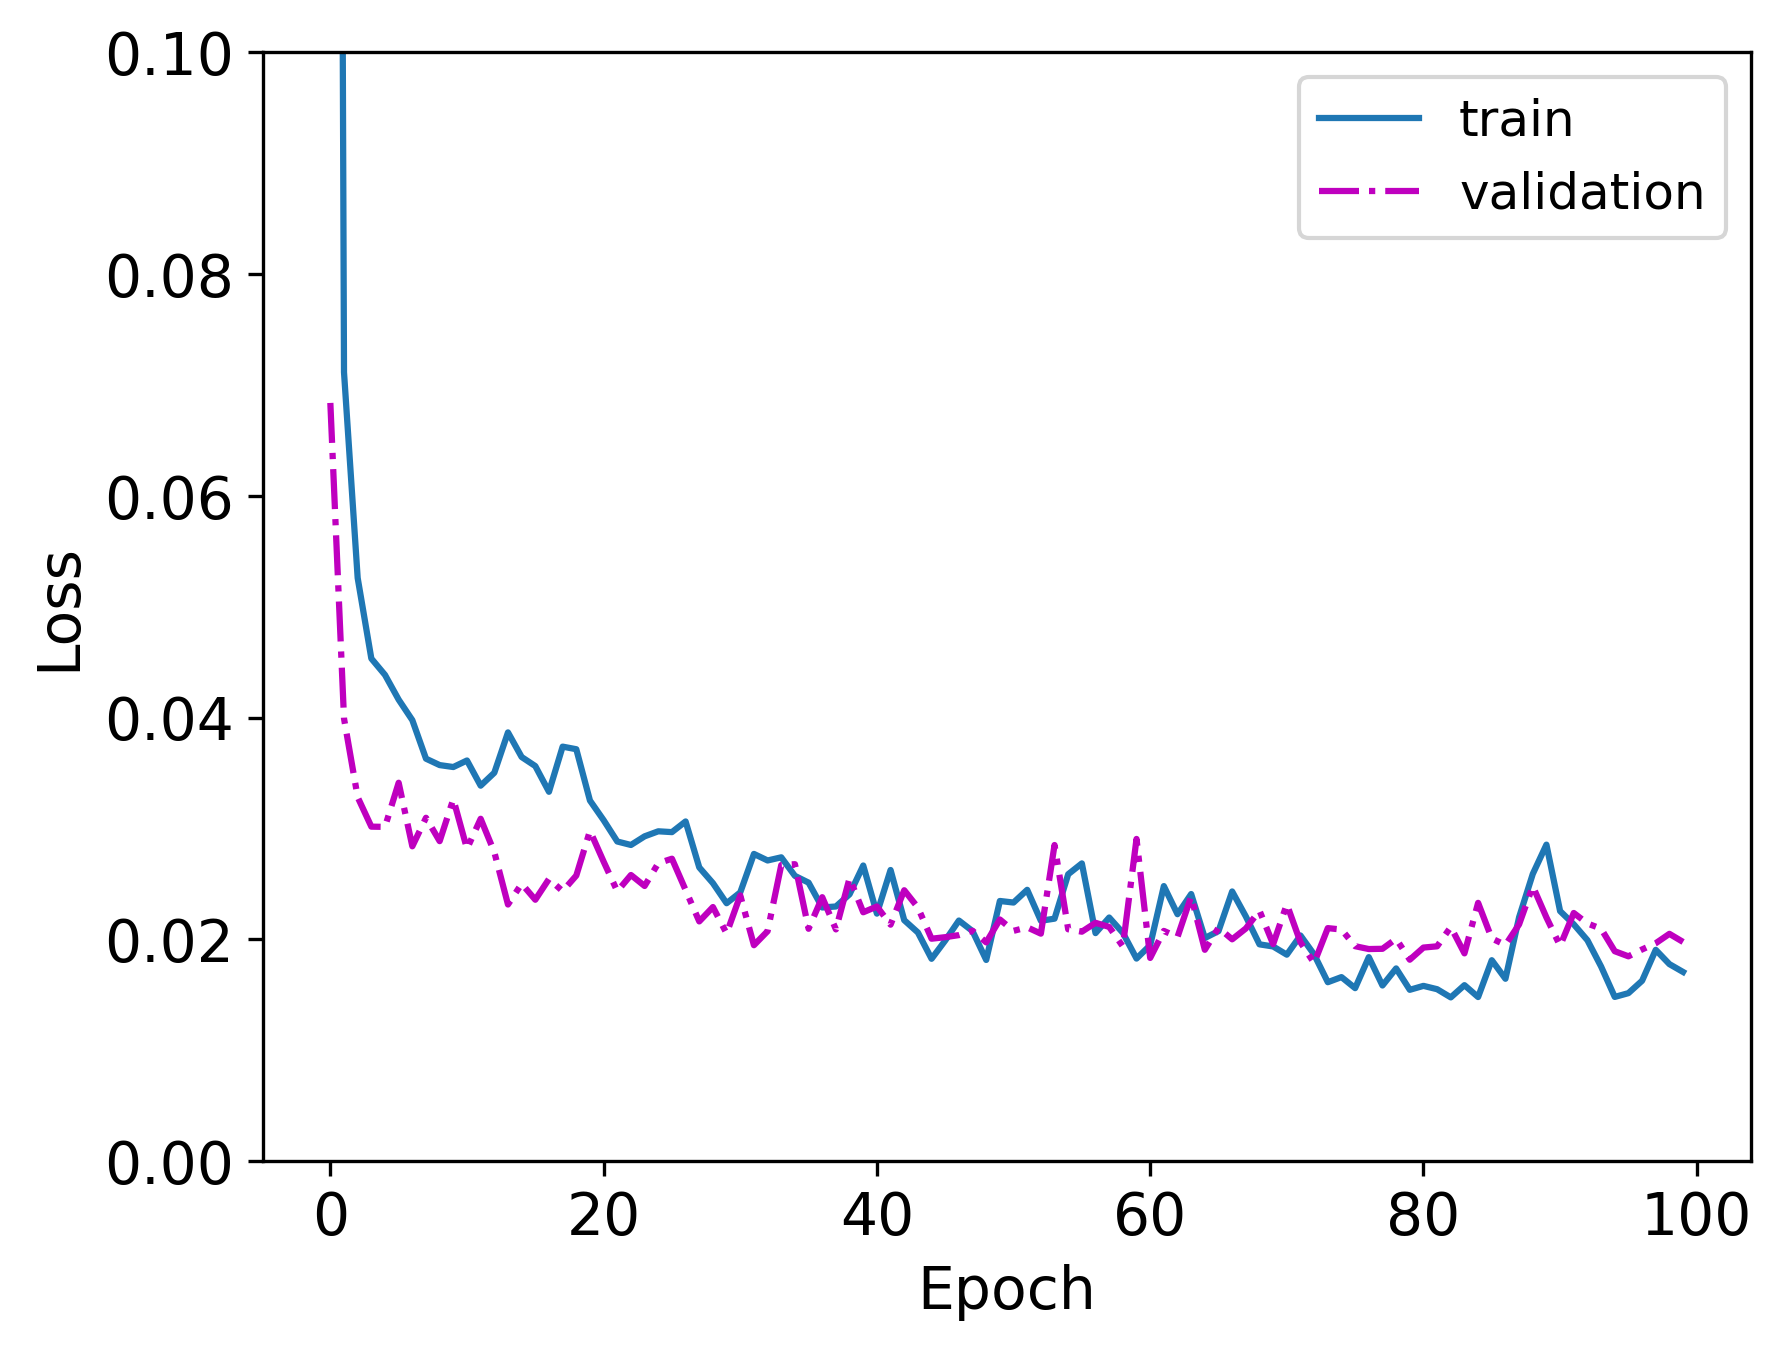

In [43]:
plt.plot(bestnet.history['loss'], label = 'train')
plt.plot(bestnet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.ylim(0,0.1)
plt.legend(loc='upper right', fontsize = 12)
plt.legend(fontsize = 12);
#plt.savefig('OptimalNN_Photoz.png',dpi=300)

Finally, we report test scores for all the metrics of interest (MSE, OLF, NMAD):

In [44]:
model.evaluate(Xst_test, y_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0282


0.02818109840154648

In [45]:
ypred = model.predict(Xst_test)

#Calculate OLF

print('OLF', len(np.where(np.abs(y_test-ypred)>0.15*(1+y_test))[0])/len(y_test))

#Calculate Normalized Median Absolute Deviation (NMAD)

print('NMAD', 1.48*np.median(np.abs(y_test-ypred)/(1 + y_test)))

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
OLF 0.034045922406967535
NMAD 0.034107957604130004


### Question:
- Are the results improved, relative to the initial baseline model? 
- Are the results improved, relative to your ensemble decision tree models?
- Does this model have high variance?
- What else would we want to do to get definite answers to these questions?

>The results have improved relative to the initial baseline model: OLF: 0.046 -> 0.034 and NMAD: 0.035 -> 0.034

>The results improved the OLF but not the NMAD, relative to the ensemble decision tree models: OLF: 0.045 -> 0.034 and NMAD: 0.032 -> 0.034

>The model does not have high variance because the train and validation losses are very similar. 

>We may want to try different loss functions to get definite answers to these questions. 

### Below, we show the effect of changing the loss function (MSE/MAE/MAPE), and we estimate the uncertainties in the estimates of OLF/NMAD, so we can decide whether the differences are significant.

#### The model is the best model I found above (it came from a Random Search, you might find a different one).

In [46]:
#this took about 5 minutes to run on my laptop
#Architecture stays the same
keras.backend.clear_session()

model = Sequential()

# Tell subsequent layers what shape to expect
model.add(keras.Input(shape=(6,)))

optimizer = keras.optimizers.AdamW(learning_rate=0.01)

# Add an input layer and specify its size (number of original features)

model.add(Dense(300, activation='relu', input_shape=(6,)))

# Add one hidden layer and specify its size

model.add(Dense(100, activation='relu'))

# Add another hidden layer and specify its size

model.add(Dense(100, activation='relu'))

# Add another hidden layer and specify its size

model.add(Dense(200, activation='relu'))

# Add an output layer 

model.add(Dense(1, activation='linear'))

#We use three different loss functions and repeat the training 4x

for loss in ['mse','mae', 'mape']:

    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate = 0.01),
        loss=loss)

    OLF = np.zeros(4)
    NMAD = np.zeros(4)

    for i in range(0,4): #let's do this 4 times and change only random weights initialization
    
        model.fit(Xst_train, y_train,
             epochs=100,
             validation_data=(Xst_val, y_val), batch_size=300, verbose = 0)

        ypred = model.predict(Xst_test)

        #Calculate OLF

        OLF[i] = len(np.where(np.abs(y_test-ypred)>0.15*(1+y_test))[0])/len(y_test)

        #Calculate Normalized Median Absolute Deviation (NMAD)
        
        NMAD[i] = 1.48*np.median(np.abs(y_test-ypred)/(1 + y_test))

    print('OLF mean/std using loss', loss, 'is:', "{:.3f}".format(OLF.mean()), "{:.3f}".format(OLF.std()))
    print('NMAD mean/std using loss', loss, 'is:', "{:.2f}".format(NMAD.mean()), "{:.3f}".format(NMAD.std()))

/opt/anaconda3/envs/phy448_deeplearning/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
OLF mean/std using loss mse is: 0.028 0.002
NMAD mean/std using loss mse is: 0.03 0.004
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
OLF mean/std using loss mae is: 0.023 0.001
NMAD mean/std using loss mae is: 0.02 0.001
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
OLF mean/std using loss mape is: 0.021 0.002
NMAD mean/std using loss mape is: 0.02 0.001


### Question:
- What are the source(s) of the variance we've measured in this test? E.g. in the past, we've measured the variance associated with changing the test set by using CV. Is that what we're doing here? If not, what causes the difference between the models we're using to get the variance on each OLF/NMAD result?

- If we want to minimize OLF and NMAD, what loss (of these default options) should we use to train our model?

>The sources of variance include the random weight initialization and the tuning is random and does not include all of the possible models. 

>We should use mape to train our model is we want to minimize OLF and NMAD. 

### Acknowledgement Statement:

>The authors acknowledge Dr. Gruszko for answering questions. 

You're done, go ahead and upload both studio notebooks to Gradescope!